In [2]:
import numpy as np
import pandas as pd 
import matplotlib as mpl

df = pd.read_csv("../data/vehiculos_procesadores.csv")

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,10) # Figuras de plt a 10x10 pulgadas

In [3]:
df.shape

(38436, 11)

In [4]:
df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706
1,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706
2,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
3,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
4,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500


In [5]:
df["modelo_unico"] = df.fabricante.str.cat([df.modelo, df.year.apply(str)],sep='-' )

In [6]:
df.modelo_unico.value_counts()

Jeep-Cherokee/Wagoneer-1985      24
Chevrolet-C10 Pickup 2WD-1984    19
GMC-C15 Pickup 2WD-1984          19
Ford-F150 Pickup 2WD-1984        19
Chevrolet-C10 Pickup 2WD-1985    18
                                 ..
GMC-Suburban 1500 2WD-1995        1
Pontiac-Aztek AWD-2003            1
Lexus-GS 350 AWD-2007             1
Hyundai-Santa Fe 4WD-2002         1
BMW-X5 xDrive50i-2016             1
Name: modelo_unico, Length: 17448, dtype: int64

In [7]:
df[df.modelo_unico=="Chevrolet-C10 Pickup 2WD-1984"].head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02,modelo_unico
4866,Chevrolet,C10 Pickup 2WD,1984,4.1,6.0,Automatic 3-spd,2-Wheel Drive,Standard Pickup Trucks 2WD,Regular,15,592.466667,Chevrolet-C10 Pickup 2WD-1984
4867,Chevrolet,C10 Pickup 2WD,1984,4.1,6.0,Automatic 4-spd,2-Wheel Drive,Standard Pickup Trucks 2WD,Regular,16,555.437500,Chevrolet-C10 Pickup 2WD-1984
4868,Chevrolet,C10 Pickup 2WD,1984,4.1,6.0,Manual 3-spd,2-Wheel Drive,Standard Pickup Trucks 2WD,Regular,17,522.764706,Chevrolet-C10 Pickup 2WD-1984
4869,Chevrolet,C10 Pickup 2WD,1984,4.1,6.0,Manual 4-spd,2-Wheel Drive,Standard Pickup Trucks 2WD,Regular,17,522.764706,Chevrolet-C10 Pickup 2WD-1984
4870,Chevrolet,C10 Pickup 2WD,1984,5.0,8.0,Automatic 3-spd,2-Wheel Drive,Standard Pickup Trucks 2WD,Regular,14,634.785714,Chevrolet-C10 Pickup 2WD-1984


In [8]:
df[df.duplicated()].shape

(1506, 12)

In [9]:
df = df.drop_duplicates()
df.shape

(36930, 12)

In [10]:
del df["modelo_unico"]
df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706
2,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
4,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500
5,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
6,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500


In [11]:
n_records = len(df)
def valores_duplicados_col(ds):
    for columna in ds:
        n_por_valor = ds[columna].value_counts()
        mas_comun = n_por_valor.iloc[0]
        menos_comun = n_por_valor.iloc[-1]
        print("{} {} {} | {}".format(
            df[columna].name,
            round(mas_comun / (1.0 * n_records),3),
            round(menos_comun / (1.0 * n_records),3),
            df[columna].dtype
        ))
valores_duplicados_col(df)

fabricante 0.1 0.0 | object
modelo 0.005 0.0 | object
year 0.038 0.007 | int64
desplazamiento 0.095 0.0 | float64
cilindros 0.38 0.0 | float64
transmision 0.287 0.0 | object
traccion 0.353 0.005 | object
clase 0.145 0.0 | object
combustible 0.652 0.0 | object
consumo 0.097 0.0 | int64
c02 0.084 0.0 | float64


In [12]:
df.traccion.value_counts(normalize=True)

Front-Wheel Drive             0.360280
Rear-Wheel Drive              0.352863
4-Wheel or All-Wheel Drive    0.177345
All-Wheel Drive               0.062325
4-Wheel Drive                 0.030886
2-Wheel Drive                 0.011402
Part-time 4-Wheel Drive       0.004899
Name: traccion, dtype: float64

<AxesSubplot:>

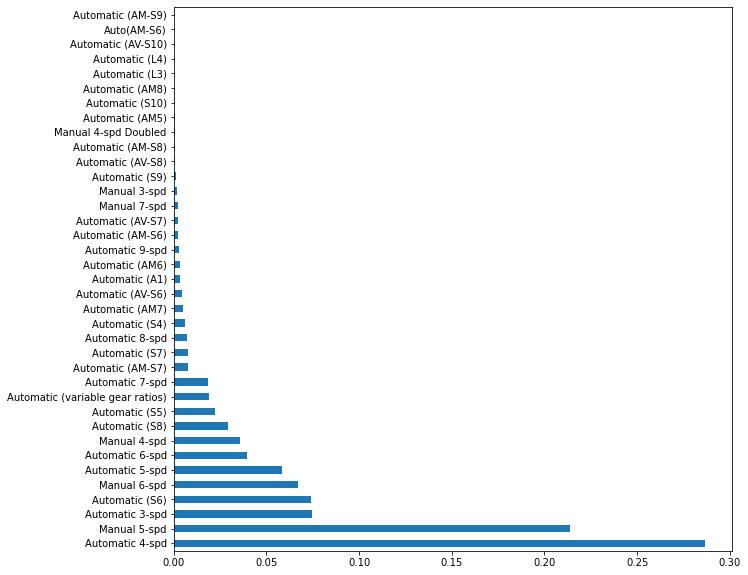

In [13]:
df.transmision.value_counts(normalize=True).plot.barh()

<AxesSubplot:>

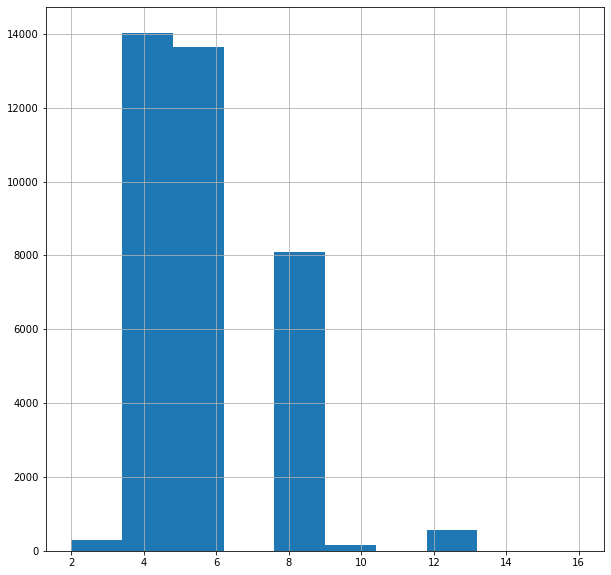

In [14]:
df.cilindros.hist()

<AxesSubplot:>

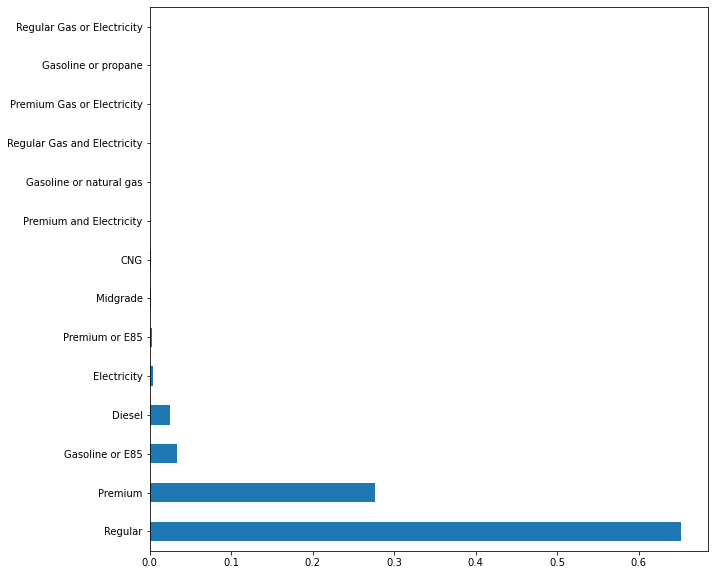

In [15]:
df.combustible.value_counts(normalize=True).plot.barh()

In [16]:
n_records = len(df)
def valores_inexistentes_col(ds):
    for columna in ds:
        print("{} | {} | {}".format(
            ds[columna].name, round(len(ds[ds[columna].isnull()]) / (1.0*n_records),3), ds[columna].dtype
        ))
        
valores_inexistentes_col(df)

fabricante | 0.0 | object
modelo | 0.0 | object
year | 0.0 | int64
desplazamiento | 0.004 | float64
cilindros | 0.004 | float64
transmision | 0.0 | object
traccion | 0.022 | object
clase | 0.0 | object
combustible | 0.0 | object
consumo | 0.0 | int64
c02 | 0.0 | float64


ZScore = Desviacion Estandar

$$z(x)= \frac{x-\mu}{\sigma}$$

In [21]:
from scipy import stats

def outliner_col(ds):
    for columna in ds:
        if ds[columna].dtype != np.object:
            n_outliners = len(ds[np.abs(stats.zscore(ds[columna])) > 3])
            print("{} | {} | {}".format(
                ds[columna].name,
                n_outliners,
                ds[columna].dtype
            ))
            
outliner_col(df)

year | 0 | int64
desplazamiento | 0 | float64
cilindros | 0 | float64
consumo | 233 | int64
c02 | 358 | float64


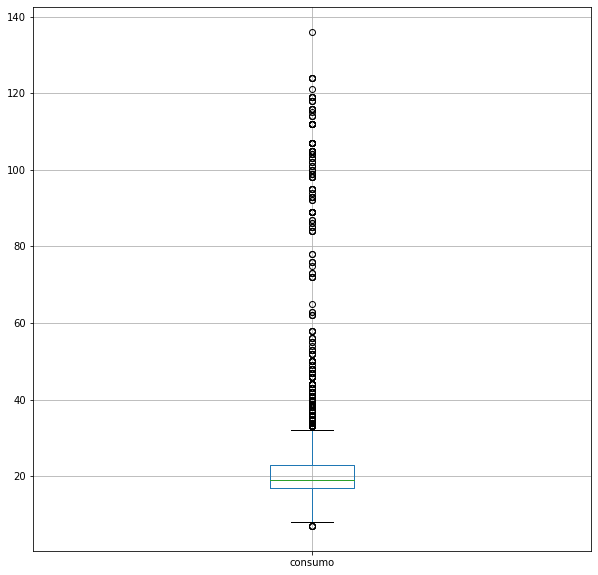

In [23]:
df.boxplot(column="consumo");

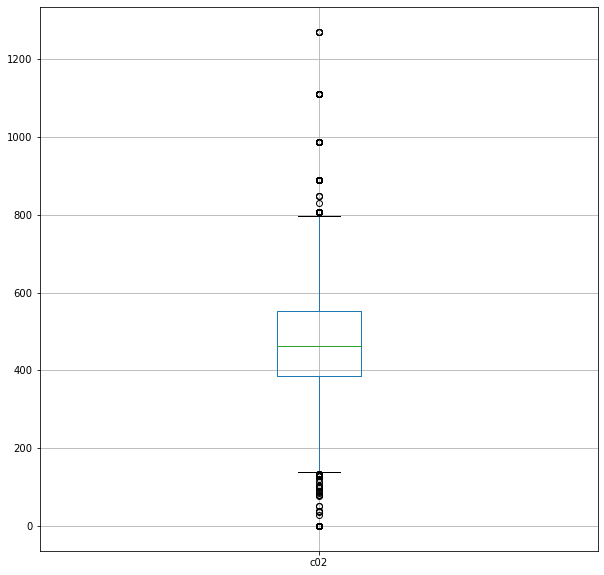

In [25]:
df.boxplot(column="c02");

In [26]:
df[df.c02==0].combustible.unique()

array(['Electricity'], dtype=object)

In [27]:
df.combustible.unique()

array(['Regular', 'Premium', 'Diesel', 'Premium and Electricity',
       'Premium or E85', 'Electricity', 'Premium Gas or Electricity',
       'Gasoline or E85', 'Gasoline or natural gas', 'CNG',
       'Regular Gas or Electricity', 'Midgrade',
       'Regular Gas and Electricity', 'Gasoline or propane'], dtype=object)

In [31]:
vehiculos_no_electricos = df[df.c02>0]
vehiculos_no_electricos.shape

(36791, 11)

In [32]:
outliner_col(vehiculos_no_electricos)

year | 0 | int64
desplazamiento | 0 | float64
cilindros | 0 | float64
consumo | 400 | int64
c02 | 221 | float64


In [33]:
valores_duplicados_col(vehiculos_no_electricos)

fabricante 0.099 0.0 | object
modelo 0.005 0.0 | object
year 0.038 0.007 | int64
desplazamiento 0.095 0.0 | float64
cilindros 0.38 0.0 | float64
transmision 0.287 0.0 | object
traccion 0.351 0.005 | object
clase 0.145 0.0 | object
combustible 0.652 0.0 | object
consumo 0.097 0.0 | int64
c02 0.084 0.0 | float64


In [34]:
valores_inexistentes_col(vehiculos_no_electricos)

fabricante | 0.0 | object
modelo | 0.0 | object
year | 0.0 | int64
desplazamiento | 0.0 | float64
cilindros | 0.0 | float64
transmision | 0.0 | object
traccion | 0.021 | object
clase | 0.0 | object
combustible | 0.0 | object
consumo | 0.0 | int64
c02 | 0.0 | float64


In [35]:
vehiculos_no_electricos.to_csv("../data/vehiculos_procesados_sin_electricos.csv", index=False)

In [36]:
duplicados = 38436 - 36791
duplicados

1645